In [17]:
library(data.table)
library(VennDiagram)

In [18]:
true_data = fread("/srv/home/mlef0011/VDARK/rawdata/448fe471-3f4e-4dc8-a4e0-6f147dc93abe.consensus.20160830.somatic.snv_mnv.vcf.gz", header=T, sep = "\t", data.table=F)
true_data = true_data[true_data$`#CHROM`== 21 ,]
head(true_data)

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
18786,21,9552228,.,G,T,.,REMAPFAIL,"Callers=broad,muse;NumCallers=2;VAF=0.3571;repeat_masker=(AAATG)n;t_alt_count=5;t_ref_count=9"
18787,21,9651052,.,G,A,.,NORMALPANEL,"1000genomes_AF=0.0013978;1000genomes_ID=rs554399099;Callers=broad,muse,sanger;NumCallers=3;VAF=0.1475;dbsnp=rs554399099;repeat_masker=LTR6A;t_alt_count=9;t_ref_count=52"
18788,21,9658622,.,G,A,.,REMAPFAIL,"Callers=broad,muse;NumCallers=2;VAF=0.0851;repeat_masker=L1PA3;t_alt_count=8;t_ref_count=86"
18789,21,9677969,.,G,C,.,REMAPFAIL,"Callers=broad,muse;NumCallers=2;VAF=0.0755;repeat_masker=AluJb;t_alt_count=4;t_ref_count=49"
18790,21,9838920,.,C,G,.,.,"Callers=broad,muse,sanger;NumCallers=3;VAF=0.2192;repeat_masker=L1PA4;t_alt_count=16;t_ref_count=57;Variant_Classification=IGR"
18791,21,9845370,.,C,T,.,NORMALPANEL;REMAPFAIL,"Callers=broad,muse,sanger;NumCallers=3;VAF=0.1148;t_alt_count=14;t_ref_count=108"


In [19]:
test_data = fread("/srv/home/mlef0011/VDARK/results/somatic_snvs_k31.tsv", data.table=F)
head(test_data)

,#CHROM,POS,REF,ALT,cluster_ID
,<chr>,<int>,<chr>,<chr>,<int>
1,21,9714083,A,G,10
2,21,10747521,G,C,87
3,21,10841651,G,C,12
4,21,11059583,T,C,83
5,21,14695445,C,T,9
6,21,15663682,T,G,37


In [26]:
true_pos <- true_data$POS
test_pos <- test_data$POS

In [27]:
well_predicted = intersect(true_pos,test_pos)
false_positive = setdiff(test_pos,true_pos)
false_negative = setdiff(true_pos,test_pos)

In [28]:
false_positive

[1]  9714083 11059583 15663682 17256829 17256831 17256834 17256836 19643809
 [9] 24792245 24792247 24792248 37405229 37405232 37405246 37953541 37953543
[17] 37953546 37953547 41735153 41735154 44756519 44756530 44756531 44756536
[25] 44756543 49549138 49549140 42287983    52995   151859    81134

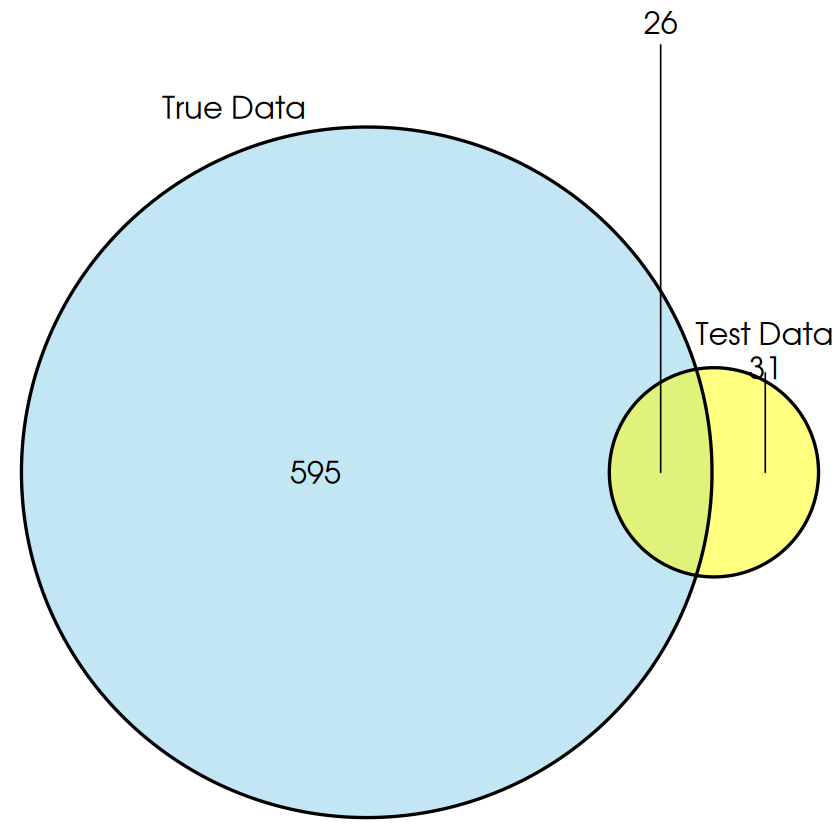

In [29]:
# Créer le diagramme de Venn
venn.plot <- draw.pairwise.venn(
  area1 = length(true_pos),
  area2 = length(test_pos),
  cross.area = length(intersect(true_pos, test_pos)),
  category = c("True Data", "Test Data"),
  fill = c("skyblue", "yellow"),
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
  cat.pos = c(-20, 20)
)

### False negative

- **tumor spccific kmer < threshold**. Example: pos 9677969 , kmer tumor specific present 3 times in tumor sample → maybe decrease tsh in KMC
- **kmer overlaping SNV can also be present in normal in other positions**. Example: pos 9838920 with k=31 → increase K (k=51) 
- **find the mutation but aligment on N-rich region in reference genome**. Example: pos 9845370 → put "asm5" option insttad of "sr" option on minimap2. 
- **considered as germline since 2/31 mutatnt kmers are in normal kmers**. Example: pos 10025691 → put threshold of minimum mutatated kmer present in normal kmers (for now tsh = 3, but to be determined)